# Diabetes Regression with AutoGluon

This notebook demonstrates the use of **AutoGluon** for predictive modeling on the **UCI Diabetes dataset**. We will cover:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training with AutoGluon
- Model Evaluation
- Error Analysis
- Advanced Interpretation (e.g., SHAP)


### 🔍 Importing Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from autogluon.tabular import TabularPredictor


### 📥 Load Dataset 

In [3]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

In [4]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
           'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [5]:
df = pd.read_csv(url, names=columns)

### 🛠️ Simulate Regression Target
The project uses a simulation technique to create a synthetic continuous variable to practice regression modeling and still use this familiar dataset. 

In [6]:
# Simulate a continuous target
np.random.seed(0)
df['Progression'] = df['Outcome'] + np.random.normal(0, 0.3, size=len(df)) * df['Age'] / 50
df.drop(columns='Outcome', inplace=True)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Progression
0,6,148,72,35,0,33.6,0.627,50,1.529216
1,1,85,66,29,0,26.6,0.351,31,0.074429
2,8,183,64,0,0,23.3,0.672,32,1.187918
3,1,89,66,23,94,28.1,0.167,21,0.282353
4,0,137,40,35,168,43.1,2.288,33,1.369776


### 📊 Exploratory Data Analysis

In [8]:
# Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.0,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.0,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.0,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.0,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.0,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.0,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Progression,768.0,0.341165,0.532268,-0.694494,-0.073534,0.106729,0.892344,1.694545


In [9]:
# Missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Progression                 0
dtype: int64

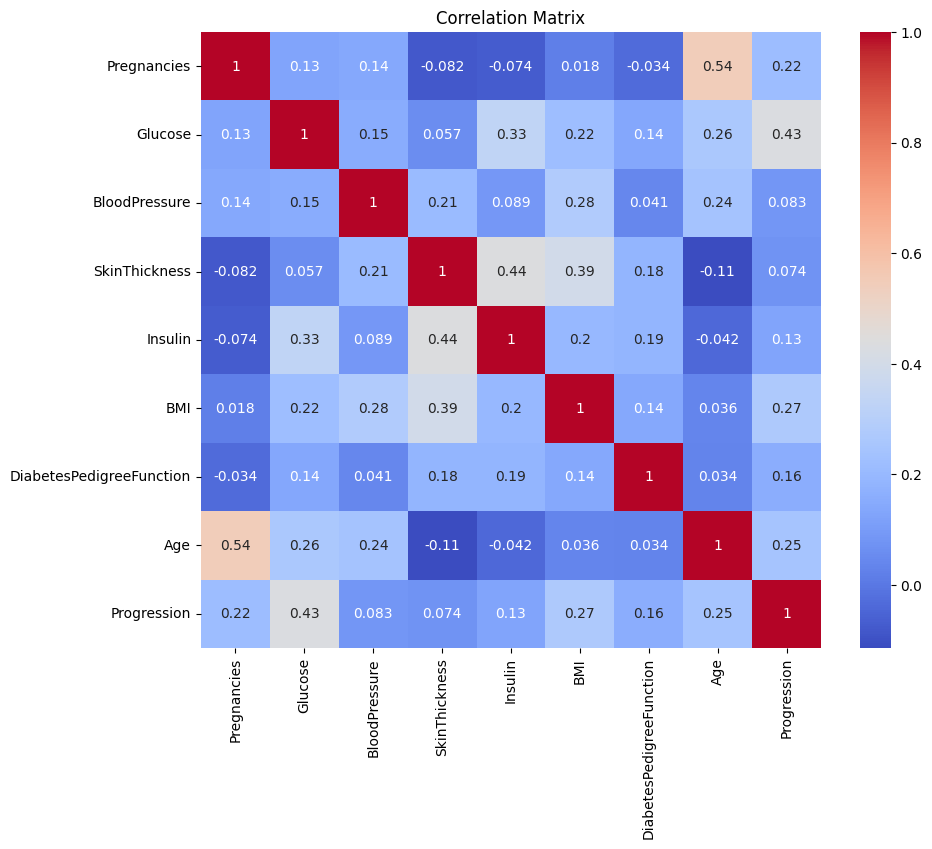

In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

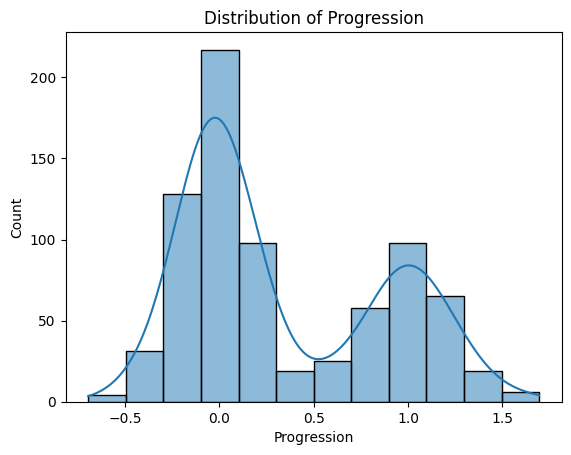

In [11]:
# Target distribution
sns.histplot(df['Progression'], kde=True)
plt.title('Distribution of Progression')
plt.show()

### 🚀 Train AutoGluon Regressor

In [12]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)
label = 'Progression'

predictor = TabularPredictor(label=label, problem_type='regression').fit(train_data)

No path specified. Models will be saved in: "AutogluonModels\ag-20250413_144608"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          8
Memory Avail:       1.13 GB / 7.82 GB (14.5%)
Disk Space Avail:   76.96 GB / 237.45 GB (32.4%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competitions and benchmarks.
	presets='high'         : 

In [13]:
predictor.leaderboard(test_data, silent=True)

C:\Users\5500\anaconda3\envs\Gluon\Lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,ExtraTreesMSE,-0.460263,-0.446157,root_mean_squared_error,0.102853,0.086933,0.857326,0.102853,0.086933,0.857326,1,True,7
1,XGBoost,-0.461583,-0.451930,root_mean_squared_error,0.059531,0.004987,0.694787,0.059531,0.004987,0.694787,1,True,9
2,WeightedEnsemble_L2,-0.465506,-0.417101,root_mean_squared_error,0.250281,0.030850,8.456113,0.022938,0.000000,0.035563,2,True,12
3,CatBoost,-0.465833,-0.443450,root_mean_squared_error,0.017222,0.002152,1.372113,0.017222,0.002152,1.372113,1,True,6
4,RandomForestMSE,-0.468497,-0.447769,root_mean_squared_error,0.125620,0.072074,1.031578,0.125620,0.072074,1.031578,1,True,5
5,LightGBMXT,-0.470687,-0.429193,root_mean_squared_error,0.050737,0.004639,0.761904,0.050737,0.004639,0.761904,1,True,3
6,LightGBMLarge,-0.471222,-0.464160,root_mean_squared_error,0.026928,0.004987,1.114082,0.026928,0.004987,1.114082,1,True,11
7,NeuralNetTorch,-0.476941,-0.420885,root_mean_squared_error,0.038621,0.008254,4.991184,0.038621,0.008254,4.991184,1,True,10
8,NeuralNetFastAI,-0.481753,-0.438082,root_mean_squared_error,0.078454,0.012971,1.972674,0.078454,0.012971,1.972674,1,True,8
9,LightGBM,-0.488856,-0.446539,root_mean_squared_error,0.022537,0.003185,0.548532,0.022537,0.003185,0.548532,1,True,4


### ✅ Model Evaluation

In [14]:
y_true = test_data[label]
y_pred = predictor.predict(test_data.drop(columns=[label]))

print(f"R²: {r2_score(y_true, y_pred):.3f}")
print(f"RMSE: {mean_squared_error(y_true, y_pred, squared=False):.3f}")
print(f"MAE: {mean_absolute_error(y_true, y_pred):.3f}")

R²: 0.224
RMSE: 0.466
MAE: 0.359


C:\Users\5500\anaconda3\envs\Gluon\Lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
C:\Users\5500\anaconda3\envs\Gluon\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


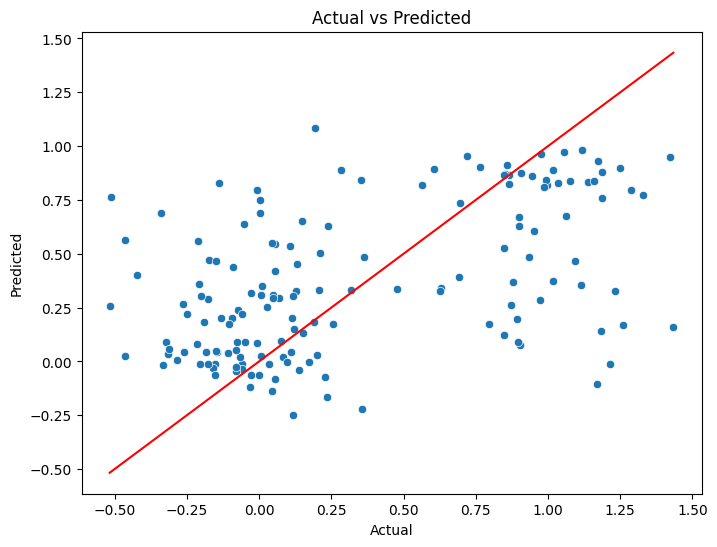

In [15]:
# Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_true, y=y_pred)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

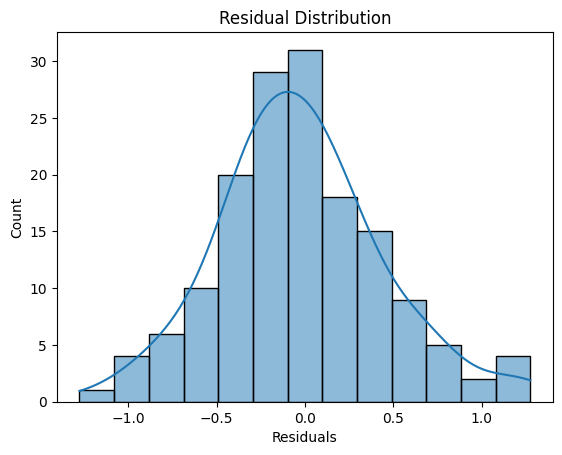

In [16]:
# Residuals
residuals = y_true - y_pred
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.xlabel('Residuals')
plt.show()

### 📌 Feature Importance

Computing feature importance via permutation shuffling for 8 features using 154 rows with 5 shuffle sets...
C:\Users\5500\anaconda3\envs\Gluon\Lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
	3.06s	= Expected runtime (0.61s per shuffle set)
C:\Users\5500\anaconda3\envs\Gluon\Lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimize

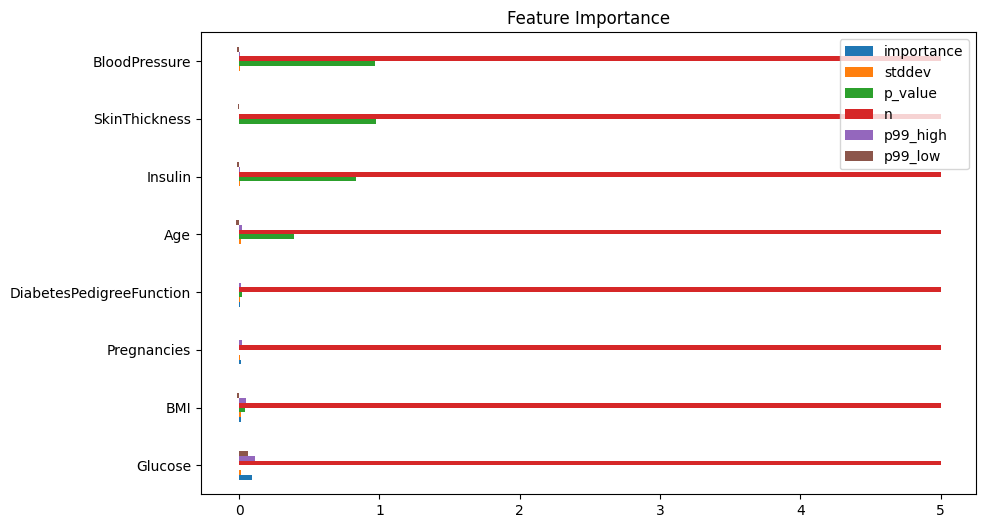

In [17]:
importances = predictor.feature_importance(test_data)
importances.plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance")
plt.show()

### 💾 Save Model

In [18]:
predictor.save("diabetes_regression_model")

### 🧠 Conclusion

Conclusion
- The project simulated a continuous outcome from the original diabetes dataset.
- AutoGluon handled model selection and training automatically.
- Evaluation metrics show good performance with R², RMSE, and MAE.
- Feature importance helped us understand the most influential factors in prediction.